# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [45]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)

In [46]:
df = pd.read_csv('credit_risk_dataset.csv', sep=None, engine='python')
df.shape

(32581, 12)

In [47]:
df.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [48]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [49]:
loan_status_dist = df['loan_status'].value_counts()
loan_status_percent = df['loan_status'].value_counts(normalize=True) * 100

loan_status_percent

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

Це задача незбалансованої класифікації. Більшість кредитів сплачується.


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [50]:
#1
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_percent

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.747000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.563856
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

In [51]:
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

In [52]:
df[['person_emp_length', 'loan_int_rate']].isnull().sum()

person_emp_length    0
loan_int_rate        0
dtype: int64

In [53]:
#2
df.select_dtypes("number").describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.767994,9589.371106,11.009620,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.087372,6322.086646,3.081611,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [54]:
#3
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['person_income'] >= lower_bound) & (df['person_income'] <= upper_bound)]

removed = len(df) - len(df_clean)

print(f"Видалено викидів: {removed}")

Видалено викидів: 1484


In [55]:
#4
# Статус кредиту і вид володіння житлом
home_loan_status = df_clean.groupby(['person_home_ownership', 'loan_status']).size().unstack()
home_loan_status_pct = home_loan_status.div(home_loan_status.sum(axis=1), axis=0) * 100

fig = px.bar(
    home_loan_status_pct.T,
    title='Статус кредиту і вид володіння житлом',
    labels={'value': 'Відсоток (%)', 'index': 'Статус кредиту'},
    color_discrete_map={'No':'#2ecc71', 'Yes':'#e74c3c'},
    barmode='group'
)
fig.show()

Ті, хто орендує житло, має більший відсоток несплати кредитів.

In [56]:
# Статус кредиту і мета кредиту
loan_intent_status = df_clean.groupby(['loan_intent', 'loan_status']).size().unstack()
loan_intent_status_pct = loan_intent_status.div(loan_intent_status.sum(axis=1), axis=0) * 100

fig = px.bar(
    loan_intent_status_pct.T,
    title='Статус кредиту і мета кредиту',
    labels={'value': 'Відсоток (%)', 'index': 'Статус кредиту'},
    color_discrete_map={'No':'#2ecc71', 'Yes':'#e74c3c'},
    barmode='group'
)
fig.show()

Найбільший відсоток неплатників серед тих, хто раніше зробив консолідацію боргу.

In [57]:
# Статус кредиту і кредитний рейтинг
loan_grade_status = df_clean.groupby(['loan_grade', 'loan_status']).size().unstack()
loan_grade_status_pct = loan_grade_status.div(loan_grade_status.sum(axis=1), axis=0) * 100

fig = px.bar(
    loan_grade_status_pct.T,
    title='Статус кредиту і кредитний рейтинг',
    labels={'value': 'Відсоток (%)', 'index': 'Статус кредиту'},
    color_discrete_map={'No':'#2ecc71', 'Yes':'#e74c3c'},
    barmode='group'
)
fig.show()

Є пряма залежність між несплатою кредитів і кредитним рейтингом.

In [58]:
# Статус кредиту та історія дефолтів
cb_person_default_on_file_status = df_clean.groupby(['cb_person_default_on_file', 'loan_status']).size().unstack()
cb_person_default_on_file_status_pct = cb_person_default_on_file_status.div(cb_person_default_on_file_status.sum(axis=1), axis=0) * 100

fig = px.bar(
    cb_person_default_on_file_status_pct.T,
    title='Статус кредиту та історія дефолтів',
    labels={'value': 'Відсоток (%)', 'index': 'Статус кредиту'},
    color_discrete_map={'No':'#2ecc71', 'Yes':'#e74c3c'},
    barmode='group'
)
fig.show()

Ті, хто раніше не сплачував кредити, частіше не сплачують і нові кредити.

In [59]:
#5
# Статус кредиту vs вік позичальника
fig = px.box(
    df_clean,
    x='loan_status',
    y='person_age',
    title='Вік позичальника vs статус кредиту',
    labels={'person_age': 'Вік', 'loan_status': 'Статус кредиту'},
    color='loan_status',
    color_discrete_map={'No':'#2ecc71', 'Yes':'#e74c3c'}
)
fig.show()

In [60]:
# Статус кредиту vs річний дохід позичальника
fig = px.box(
    df_clean,
    x='loan_status',
    y='person_income',
    title='Річний дохід позичальника vs статус кредиту',
    labels={'person_income': 'Дохід', 'loan_status': 'Статус кредиту'},
    color='loan_status',
    color_discrete_map={'No':'#2ecc71', 'Yes':'#e74c3c'}
)
fig.show()

In [61]:
# Статус кредиту vs стаж роботи (в роках)
fig = px.box(
    df_clean,
    x='loan_status',
    y='person_emp_length',
    title='Стаж роботи (в роках) vs статус кредиту',
    labels={'person_emp_length': 'Стаж роботи', 'loan_status': 'Статус кредиту'},
    color='loan_status',
    color_discrete_map={'No':'#2ecc71', 'Yes':'#e74c3c'}
)
fig.show()

In [62]:
# Статус кредиту vs сума кредиту
fig = px.box(
    df_clean,
    x='loan_status',
    y='loan_amnt',
    title='Сума кредиту vs статус кредиту',
    labels={'loan_amnt': 'Сума кредиту', 'loan_status': 'Статус кредиту'},
    color='loan_status',
    color_discrete_map={'No':'#2ecc71', 'Yes':'#e74c3c'}
)
fig.show()


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



In [63]:
#1
metrics_df = df_clean[['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']].dropna()

correlation_matrix = metrics_df.corr()

fig = px.imshow(
    correlation_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляція між метриками взаємодії',
    labels=dict(color="Кореляція")
)
fig.update_layout(height=500)
fig.show()

In [64]:
#2
person_home_ownership_dummies = pd.get_dummies(df_clean['person_home_ownership'], prefix='person_home_ownership')
person_home_ownership_dummies.head().astype(int)
df_clean = pd.concat([df_clean, person_home_ownership_dummies], axis=1)

In [65]:
loan_intent_dummies = pd.get_dummies(df_clean['loan_intent'], prefix='loan_intent')
loan_intent_dummies.head().astype(int)
df_clean = pd.concat([df_clean, loan_intent_dummies], axis=1)

In [66]:
loan_grade_dummies = pd.get_dummies(df_clean['loan_grade'], prefix='loan_grade')
loan_grade_dummies.head().astype(int)
df_clean = pd.concat([df_clean, loan_grade_dummies], axis=1)

In [67]:
cb_person_default_on_file_dummies = pd.get_dummies(df_clean['cb_person_default_on_file'], prefix='cb_person_default_on_file')
cb_person_default_on_file_dummies.head().astype(int)
df_clean = pd.concat([df_clean, cb_person_default_on_file_dummies], axis=1)

In [68]:
#3
corr_features = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
features = corr_features + person_home_ownership_dummies.columns.tolist() + loan_intent_dummies.columns.tolist() + loan_grade_dummies.columns.tolist() + cb_person_default_on_file_dummies.columns.tolist()


---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [70]:
#1
X = df_clean[features]  # Ознаки
y = df_clean['loan_status']  # Цільова змінна
print(f"\nРозмір X (ознак): {X.shape}")
print(f"Розмір y (цілі): {y.shape}")


Розмір X (ознак): (31097, 26)
Розмір y (цілі): (31097,)


In [72]:
#2
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

print(f"Train: {X_train.shape[0]} кредитних клієнтів")
print(f"Test: {X_test.shape[0]} кредитних клієнтів")
print(f"Дефолт в train: {y_train.mean():.1%}")
print(f"Дефолт в test: {y_test.mean():.1%}")

Train: 24877 кредитних клієнтів
Test: 6220 кредитних клієнтів
Дефолт в train: 22.4%
Дефолт в test: 22.4%


In [ ]:
#3
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [74]:
#4
from sklearn.linear_model import LogisticRegression

# Створюємо та навчаємо модель
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Модель навчена!")

Модель навчена!


In [75]:
#5
# Прогнозуємо класи
y_pred = model.predict(X_test_scaled)

# Прогнозуємо ймовірності
y_pred_proba = model.predict_proba(X_test_scaled)

In [76]:
y_pred_proba

array([[0.96859403, 0.03140597],
       [0.98643455, 0.01356545],
       [0.96515685, 0.03484315],
       ...,
       [0.46154115, 0.53845885],
       [0.92474793, 0.07525207],
       [0.9924208 , 0.0075792 ]], shape=(6220, 2))

In [77]:
(y_pred_proba[:, 1]>0.6).astype(int)

array([0, 0, 0, ..., 0, 0, 0], shape=(6220,))

In [ ]:
sample_predictions = pd.DataFrame({
    'Реальний дефолт': y_test.values[:100],
    'Прогноз': y_pred[:100],
    'Ймовірність виплати кредиту': y_pred_proba[:100, 0].round(3),
    'Ймовірність дефолту': y_pred_proba[:100, 1].round(3)
})
print(sample_predictions)

    Реальний дефолт  Прогноз  Ймовірність виплати кредиту  Ймовірність дефолту
0                 0        0                        0.969                0.031
1                 0        0                        0.986                0.014
2                 0        0                        0.965                0.035
3                 0        0                        0.966                0.034
4                 0        1                        0.164                0.836
..              ...      ...                          ...                  ...
95                0        0                        0.966                0.034
96                0        0                        0.908                0.092
97                0        0                        0.994                0.006
98                1        1                        0.019                0.981
99                0        0                        0.992                0.008

[100 rows x 4 columns]



---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


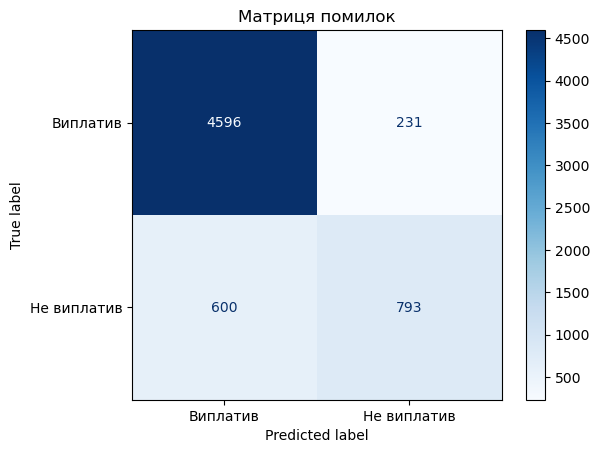

In [82]:
#1
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Виплатив', 'Не виплатив'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок')
plt.show()

In [83]:
#2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("МЕТРИКИ ЯКОСТІ МОДЕЛІ:")
print(f"Accuracy (Точність):    {accuracy:.3f}")
print(f"Precision (Влучність):  {precision:.3f}")
print(f"Recall (Повнота):       {recall:.3f}")
print(f"F1-score:               {f1:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ:
Accuracy (Точність):    0.866
Precision (Влучність):  0.774
Recall (Повнота):       0.569
F1-score:               0.656


In [84]:
#3
from sklearn.metrics import roc_curve, roc_auc_score

# Обчислюємо ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
auc = roc_auc_score(y_test, y_pred_proba[:, 1])

# Візуалізація
fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC (AUC = {auc:.3f})'))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'),
                        name='Випадковий класифікатор'))
fig.update_layout(
    title='ROC-крива',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    height=500
)
fig.show()

In [85]:
#4
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'abs_coefficient': np.abs(model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

feature_importance

,feature,coefficient,abs_coefficient
5,loan_percent_income,1.320707,1.320707
20,loan_grade_D,0.599769,0.599769
3,loan_amnt,-0.548845,0.548845
9,person_home_ownership_OWN,-0.495781,0.495781
21,loan_grade_E,0.362341,0.362341
10,person_home_ownership_RENT,0.335211,0.335211
17,loan_grade_A,-0.317120,0.317120
23,loan_grade_G,0.278437,0.278437
16,loan_intent_VENTURE,-0.228432,0.228432
22,loan_grade_F,0.212319,0.212319


5. Найбільше впливають на прогноз такі ознаки, як: відношення кредиту до доходу, кредитний рейтинг D, сума кредиту (-0.548845 означає, що чим більший кредит, тим більша ймовірність, що його виплатять; скоріше за все це пов'язано з низьким кредитним рейтингом, за якого людині не дадуть великий кредит), тип володіння житлом "Власник" (-0.495781 означає, що власники житла з більшою ймовірністю виплатять кредит).
Оскільки AUC = 0.874, можна зробити висновок, що модель хороша.


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



In [86]:
#1
thresholds = np.arange(0.1, 0.9, 0.05)
metrics_by_threshold = []

for threshold in thresholds:
    y_pred_custom = (y_pred_proba[:, 1] >= threshold).astype(int)

    metrics_by_threshold.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_custom),
        'recall': recall_score(y_test, y_pred_custom),
        'f1': f1_score(y_test, y_pred_custom)
    })

metrics_df = pd.DataFrame(metrics_by_threshold)

# Візуалізація
fig = px.line(
    metrics_df.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    title='Метрики при різних порогах рішення',
    labels={'value': 'Значення метрики', 'threshold': 'Поріг'},
)
fig.show()

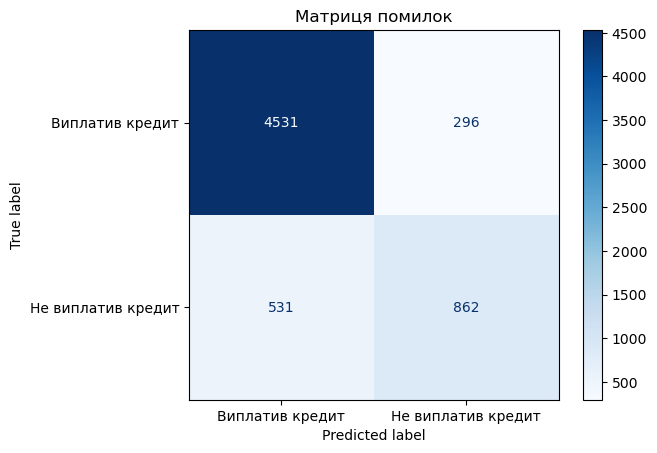

In [88]:
y_pred_opt = y_pred_proba[:,1]>=0.45
cm = confusion_matrix(y_test, y_pred_opt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Виплатив кредит', 'Не виплатив кредит'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок')
plt.show()

2. Тобто оптимальний поріг, який оптимізує точність - 0.35


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [89]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Навчаємо альтернативні моделі
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

                 Model  Accuracy  Precision  Recall     F1    AUC
0  Logistic Regression     0.866      0.774   0.569  0.656  0.874
1        Decision Tree     0.903      0.986   0.574  0.725  0.872
2        Random Forest     0.930      0.969   0.710  0.819  0.929


Найкращий результат на тестовому наборі дає модель Random Forest.